# Flowlytics: Real-Time Funnel Intelligence Platform

### MySQL Server Connection

In [15]:
import mysql.connector
import random

cnx = mysql.connector.connect(
    host="127.0.0.1",
    user="root",
    password="Chemis@123try",
    database="funnel_analytics"
)

cursor = cnx.cursor()

### Data Generator

In [16]:
event_types = ['signup', 'subscribe', 'usage', 'churn']

for _ in range(1000):   # fixed amount (no infinite loop)
    account_id = random.randint(1, 200)
    event = random.choice(event_types)
    usage = random.randint(1, 100) if event == 'usage' else 0

    cursor.execute("""
        INSERT INTO event_stream (account_id, event_type, feature_usage_count)
        VALUES (%s, %s, %s)
    """, (account_id, event, usage))

cnx.commit()
print("✅ Data inserted successfully")

✅ Data inserted successfully


### PIPELINE TRANSFORMATION

In [17]:
cursor.execute("""
REPLACE INTO realtime_funnel
SELECT 
    account_id,
    MAX(CASE WHEN event_type = 'signup' THEN 1 ELSE 0 END),
    MAX(CASE WHEN event_type = 'subscribe' THEN 1 ELSE 0 END),
    MAX(feature_usage_count),
    MAX(CASE WHEN event_type = 'churn' THEN 1 ELSE 0 END)
FROM event_stream
GROUP BY account_id
""")

cnx.commit()
print("✅ Funnel table updated")

✅ Funnel table updated


In [18]:
df = pd.read_sql("SELECT * FROM realtime_funnel", cnx)

# ✅ Handle empty case
if df.empty:
    print("❌ No data found. Run data generator first.")
    exit()

C:\Users\Veer Bajpai\AppData\Local\Temp\ipykernel_21360\3865844664.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql("SELECT * FROM realtime_funnel", cnx)


In [19]:
# 🔹 Create funnel stage
def get_stage(row):
    if row['churned'] == 1:
        return 'Churned'
    elif row['usage_count'] > 50:
        return 'Power User'
    elif row['usage_count'] > 0:
        return 'Active'
    elif row['subscribed'] == 1:
        return 'Subscribed'
    else:
        return 'Signup'

df['stage'] = df.apply(get_stage, axis=1)

# 🔹 Flags
df['converted'] = df['stage'].isin(['Subscribed','Active','Power User']).astype(int)

### 📊 GRAPH 1: Funnel Distribution

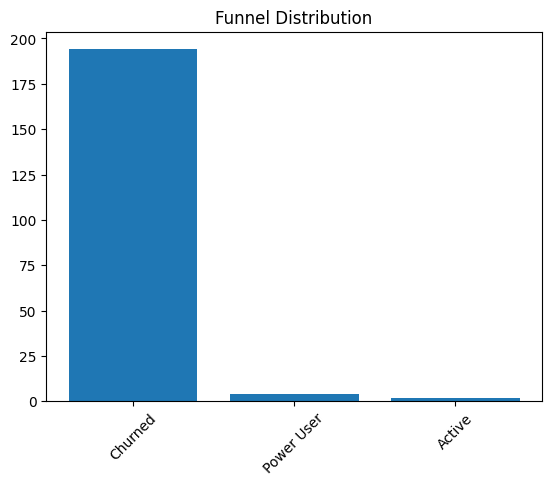

Insight: Most users are in → Churned


In [20]:
funnel = df['stage'].value_counts()

plt.figure()
plt.bar(funnel.index, funnel.values)
plt.title("Funnel Distribution")
plt.xticks(rotation=45)
plt.show()

print("Insight: Most users are in →", funnel.idxmax())

### 📊 GRAPH 2: Conversion Rate

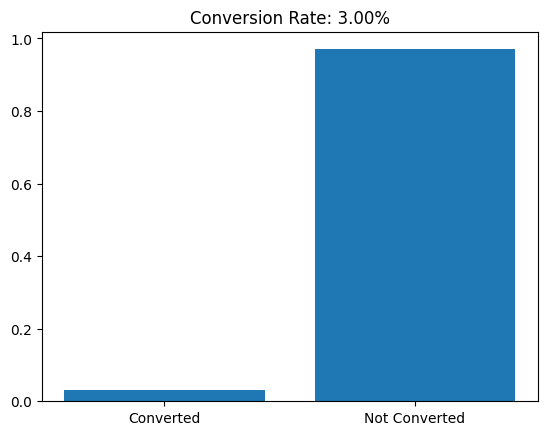

Insight: Conversion Rate = 0.03


In [21]:
conversion_rate = df['converted'].mean()

plt.figure()
plt.bar(['Converted','Not Converted'], [conversion_rate,1-conversion_rate])
plt.title(f"Conversion Rate: {conversion_rate:.2%}")
plt.show()

print("Insight: Conversion Rate =", round(conversion_rate,2))


### 📊 GRAPH 3: Churn Rate

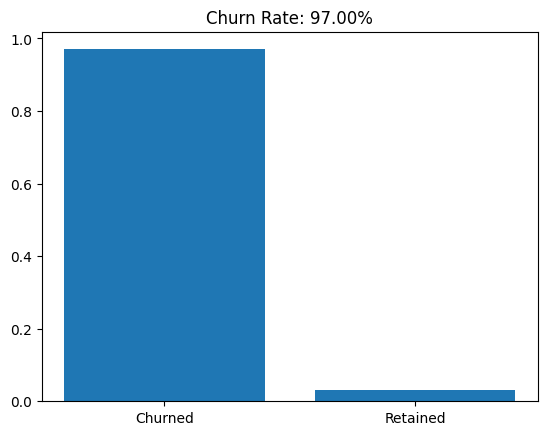

Insight: Churn Rate = 0.97


In [22]:
churn_rate = df['churned'].mean()

plt.figure()
plt.bar(['Churned','Retained'], [churn_rate,1-churn_rate])
plt.title(f"Churn Rate: {churn_rate:.2%}")
plt.show()

print("Insight: Churn Rate =", round(churn_rate,2))

### 📊 GRAPH 4: Usage by Stage

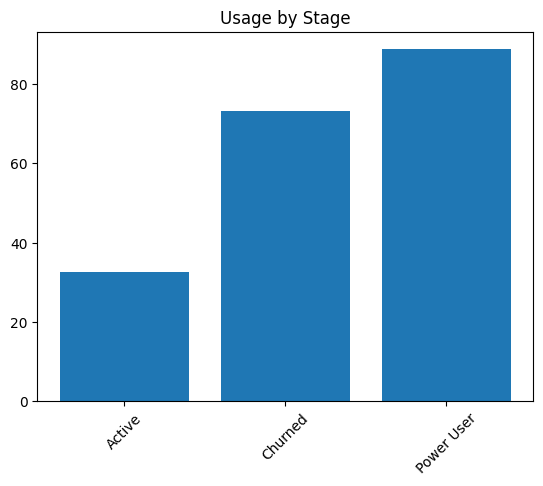

Insight: Higher usage → higher retention


In [23]:
usage_summary = df.groupby('stage')['usage_count'].mean()

plt.figure()
plt.bar(usage_summary.index, usage_summary.values)
plt.title("Usage by Stage")
plt.xticks(rotation=45)
plt.show()

print("Insight: Higher usage → higher retention")

### 📊 GRAPH 5: Correlation Matrix

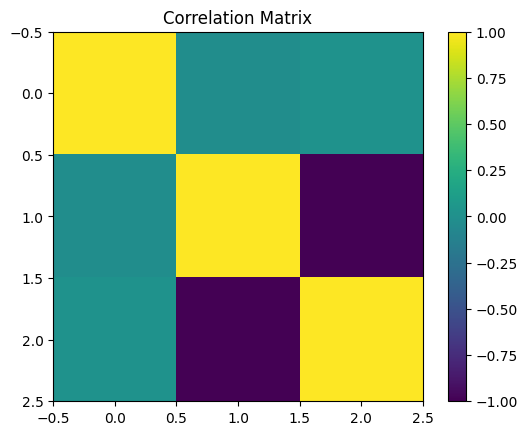

Insight: Usage negatively correlates with churn


In [25]:
corr = df[['usage_count','converted','churned']].corr()

plt.figure()
plt.imshow(corr)
plt.colorbar()
plt.title("Correlation Matrix")
plt.show()

print("Insight: Usage negatively correlates with churn")